In [1]:
# Week 4: Predictive Modeling and Optimization in Logistics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load logistics dataset

df = pd.read_csv('/content/Week2_Logistics_Cleaned_Data.csv')

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (2001, 17)


,Shipment_ID,Order_Date,Shipping_Mode,Region,Market,Product_Category,Priority,Distance_km,Shipment_Weight_kg,Order_Quantity,Scheduled_Days,Actual_Delivery_Days,Shipping_Cost,Sales_Value,Delay_Days,On_Time,Cost_per_Unit
0,SHP100000,2017-01-01 00:00:00.000000000,Second Class,South America,LATAM,Technology,Critical,1104.97,14.48,1,3,4,100.180,159.44,1,0,100.180000
1,SHP100001,2017-01-01 04:22:55.887943971,Standard Class,Western Europe,LATAM,Clothing,Medium,707.31,10.00,3,4,4,79.800,357.00,0,1,26.600000
2,SHP100002,2017-01-01 08:45:51.775887943,Standard Class,Oceania,Africa,Office Supplies,High,657.17,18.20,3,4,4,84.650,192.87,0,1,28.216667
3,SHP100003,2017-01-01 13:08:47.663831915,Standard Class,South America,Pacific Asia,Clothing,High,657.17,7.30,3,4,5,59.370,375.83,1,0,19.790000
4,SHP100004,2017-01-01 17:31:43.551775887,Same Day,Eastern Asia,USCA,Sports,High,2084.19,12.47,3,1,3,172.335,439.99,2,0,57.445000


In [3]:
# Dataset information

print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Column Names:
['Shipment_ID', 'Order_Date', 'Shipping_Mode', 'Region', 'Market', 'Product_Category', 'Priority', 'Distance_km', 'Shipment_Weight_kg', 'Order_Quantity', 'Scheduled_Days', 'Actual_Delivery_Days', 'Shipping_Cost', 'Sales_Value', 'Delay_Days', 'On_Time', 'Cost_per_Unit']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Shipment_ID           2001 non-null   object 
 1   Order_Date            2001 non-null   object 
 2   Shipping_Mode         2001 non-null   object 
 3   Region                2001 non-null   object 
 4   Market                2001 non-null   object 
 5   Product_Category      2001 non-null   object 
 6   Priority              2001 non-null   object 
 7   Distance_km           2001 non-null   float64
 8   Shipment_Weight_kg    2001 non-null   float64
 9   Order_Quantity       

In [4]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values[missing_values > 0])

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:


,0



Total Missing Values: 0


## 1. Problem Definition

The objective of this project is to develop a machine learning model that predicts the actual number of days required to deliver a shipment.

The target variable is **Actual_Delivery_Days**.

The model uses shipment information that is available before or at the time of dispatch, including distance, shipment weight, order quantity, scheduled delivery time, shipping mode, region, product category, and priority.

The prediction can help logistics managers identify shipments that are likely to exceed their scheduled delivery time and take proactive corrective actions.

Variables such as **Delay_Days** and **On_Time** are excluded from the prediction features because they are derived from the actual delivery outcome and would cause data leakage.

In [5]:
# Define target and predictor variables

target = 'Actual_Delivery_Days'

numeric_features = [
    'Distance_km',
    'Shipment_Weight_kg',
    'Order_Quantity',
    'Scheduled_Days'
]

categorical_features = [
    'Shipping_Mode',
    'Region',
    'Product_Category',
    'Priority'
]

X = df[numeric_features + categorical_features]
y = df[target]

print("Target variable:", target)
print("Number of features:", X.shape[1])
print("Number of records:", X.shape[0])

Target variable: Actual_Delivery_Days
Number of features: 8
Number of records: 2001


In [6]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 1600
Testing records: 401


## 2. Data Preprocessing

The dataset contains both numerical and categorical variables. Numerical features are handled using median imputation and standardization, while categorical features are converted into numerical form using one-hot encoding.

A preprocessing pipeline is used to ensure that the same transformations are applied consistently to both training and testing data.

In [7]:
# Create preprocessing pipelines

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 3. Predictive Model Development

Three regression algorithms are implemented and compared:

1. **Linear Regression** – used as a simple and interpretable baseline.
2. **Random Forest Regressor** – captures nonlinear relationships and interactions between logistics variables.
3. **Gradient Boosting Regressor** – combines multiple weak learners sequentially to improve prediction accuracy.

The models are evaluated on the unseen testing dataset.

In [8]:
# Define predictive models

models = {
    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models defined:")
for model_name in models:
    print("-", model_name)

Models defined:
- Linear Regression
- Random Forest
- Gradient Boosting


In [9]:
# Train and evaluate all models

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Store model and predictions
    fitted_models[name] = pipeline
    predictions[name] = y_pred

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE (days)': mae,
        'RMSE (days)': rmse,
        'R²': r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='RMSE (days)'
).reset_index(drop=True)

display(results_df)

,Model,MAE (days),RMSE (days),R²
0,Linear Regression,0.981738,1.204456,0.365065
1,Gradient Boosting,0.998723,1.227157,0.340906
2,Random Forest,1.014790,1.247054,0.319360


In [10]:
# Select the best model based on RMSE

best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best Model:", best_model_name)

print(
    f"MAE: {mean_absolute_error(y_test, best_predictions):.3f} days"
)

print(
    f"RMSE: {np.sqrt(mean_squared_error(y_test, best_predictions)):.3f} days"
)

print(
    f"R²: {r2_score(y_test, best_predictions):.3f}"
)

Best Model: Linear Regression
MAE: 0.982 days
RMSE: 1.204 days
R²: 0.365


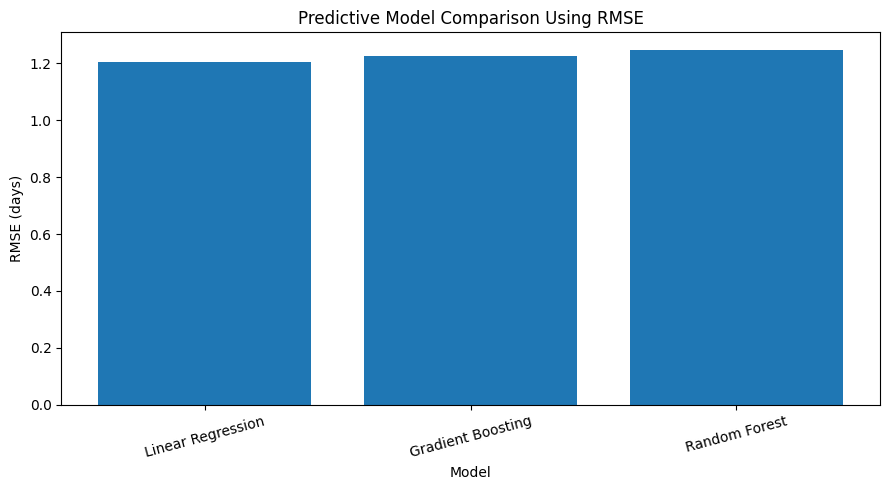

In [11]:
# Model comparison using RMSE

plt.figure(figsize=(9, 5))

plt.bar(
    results_df['Model'],
    results_df['RMSE (days)']
)

plt.xlabel('Model')
plt.ylabel('RMSE (days)')
plt.title('Predictive Model Comparison Using RMSE')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

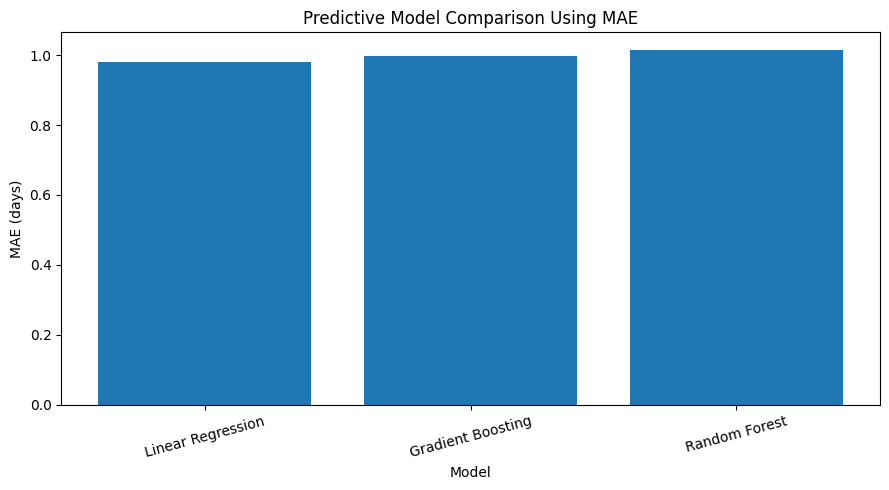

In [12]:
# Model comparison using MAE

plt.figure(figsize=(9, 5))

plt.bar(
    results_df['Model'],
    results_df['MAE (days)']
)

plt.xlabel('Model')
plt.ylabel('MAE (days)')
plt.title('Predictive Model Comparison Using MAE')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Cross-Validation

To verify that the selected model is not dependent on a single train-test split, 5-fold cross-validation is performed. The dataset is divided into five subsets, with each subset used once as the validation set while the remaining subsets are used for training.

Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are calculated across the five folds.

In [13]:
# 5-Fold Cross-Validation for the Best Model

cv_mae = -cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

cv_rmse = np.sqrt(
    -cross_val_score(
        best_model,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

print("5-Fold Cross-Validation Results")
print("--------------------------------")

print(f"Mean MAE  : {cv_mae.mean():.3f} days")
print(f"Std MAE   : {cv_mae.std():.3f} days")

print(f"Mean RMSE : {cv_rmse.mean():.3f} days")
print(f"Std RMSE  : {cv_rmse.std():.3f} days")

5-Fold Cross-Validation Results
--------------------------------
Mean MAE  : 0.977 days
Std MAE   : 0.034 days
Mean RMSE : 1.188 days
Std RMSE  : 0.045 days


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on unseen test data
y_pred = best_model.predict(X_test)

# Calculate metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Final Test Set Results")
print("----------------------")
print(f"MAE  : {test_mae:.3f} days")
print(f"RMSE : {test_rmse:.3f} days")
print(f"R²   : {test_r2:.3f}")

Final Test Set Results
----------------------
MAE  : 0.982 days
RMSE : 1.204 days
R²   : 0.365


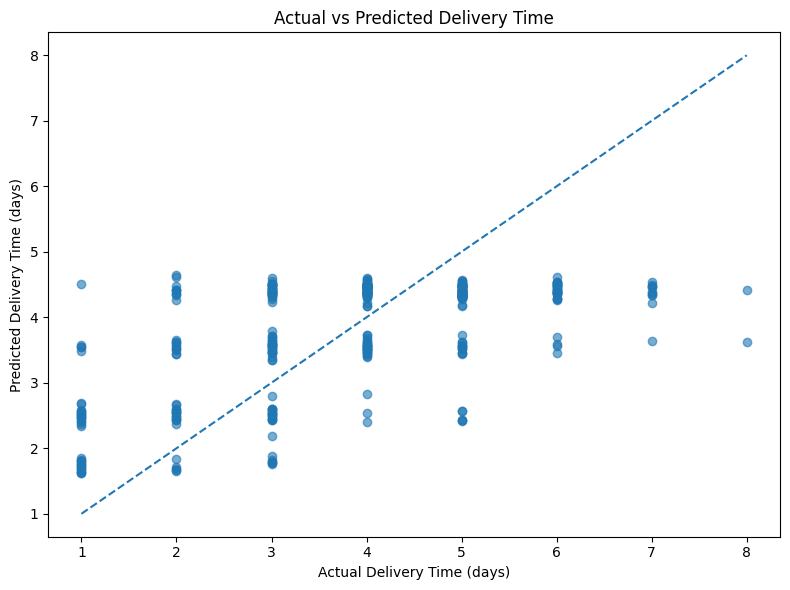

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Delivery Time (days)")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("Actual vs Predicted Delivery Time")

plt.tight_layout()
plt.show()

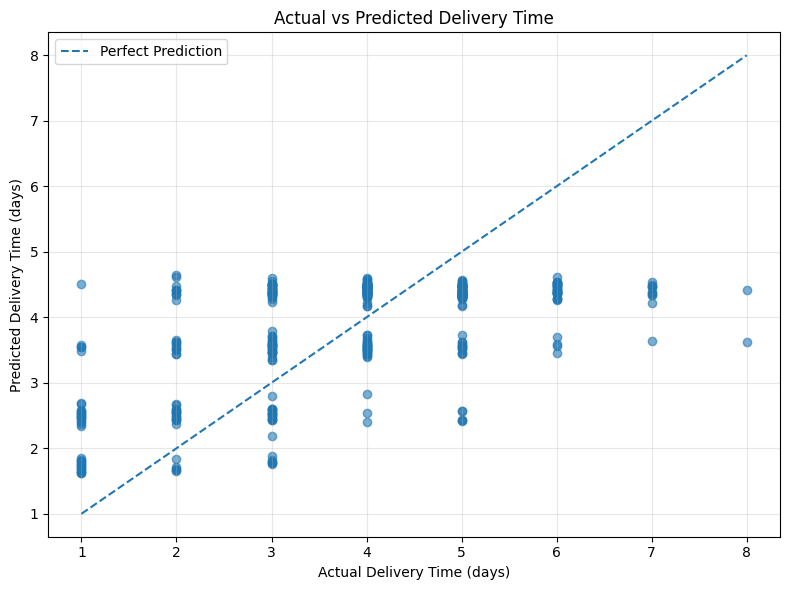

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(np.min(y_test), np.min(y_pred))
max_val = max(np.max(y_test), np.max(y_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual Delivery Time (days)")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("Actual vs Predicted Delivery Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Calculate prediction errors
errors = y_test - y_pred

print("Actual vs Predicted Analysis")
print("----------------------------")
print(f"Number of test samples : {len(y_test)}")
print(f"Mean error             : {errors.mean():.3f} days")
print(f"Minimum error          : {errors.min():.3f} days")
print(f"Maximum error          : {errors.max():.3f} days")
print(f"Mean absolute error    : {np.mean(np.abs(errors)):.3f} days")

# Correlation between actual and predicted
correlation = np.corrcoef(y_test, y_pred)[0, 1]

print(f"Correlation            : {correlation:.3f}")

Actual vs Predicted Analysis
----------------------------
Number of test samples : 401
Mean error             : 0.031 days
Minimum error          : -3.505 days
Maximum error          : 4.371 days
Mean absolute error    : 0.982 days
Correlation            : 0.605


Residual Analysis

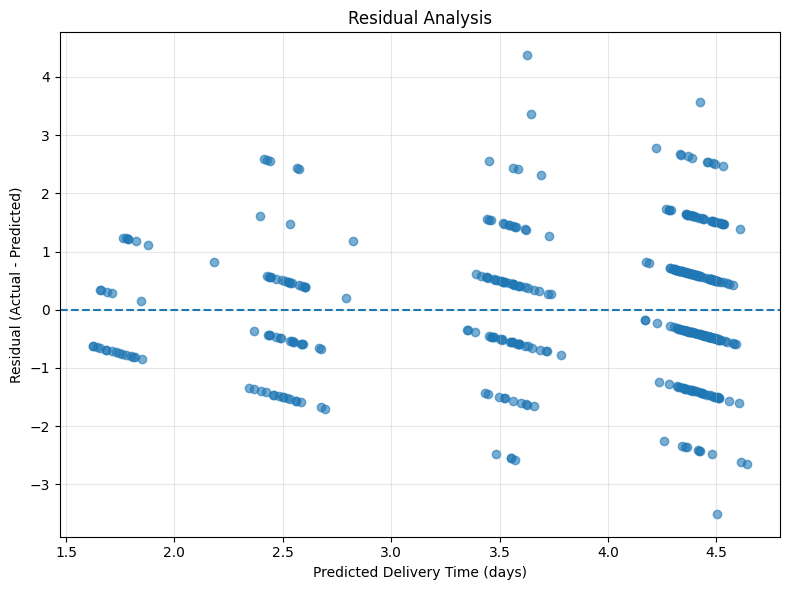

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

# Zero-error reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Delivery Time (days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
print("Residual Analysis")
print("-----------------")
print(f"Mean residual       : {residuals.mean():.3f}")
print(f"Std residual        : {residuals.std():.3f}")
print(f"Minimum residual    : {residuals.min():.3f}")
print(f"Maximum residual    : {residuals.max():.3f}")

# Percentage of predictions within different error ranges
within_1 = np.mean(np.abs(residuals) <= 1) * 100
within_2 = np.mean(np.abs(residuals) <= 2) * 100
within_3 = np.mean(np.abs(residuals) <= 3) * 100

print(f"Within ±1 day       : {within_1:.2f}%")
print(f"Within ±2 days      : {within_2:.2f}%")
print(f"Within ±3 days      : {within_3:.2f}%")

Residual Analysis
-----------------
Mean residual       : 0.031
Std residual        : 1.206
Minimum residual    : -3.505
Maximum residual    : 4.371
Within ±1 day       : 62.59%
Within ±2 days      : 90.77%
Within ±3 days      : 99.00%


In [21]:
print("Best Model:", type(best_model).__name__)

Best Model: Pipeline


In [22]:
print(best_model)
print(best_model.named_steps)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Distance_km',
                                                   'Shipment_Weight_kg',
                                                   'Order_Quantity',
                                                   'Scheduled_Days']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                          

In [23]:
# Get the preprocessor and linear regression model
preprocessor = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get regression coefficients
coefficients = model.coef_

# Create feature importance table
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    by='Absolute_Importance',
    ascending=False
)

print("Feature Importance / Regression Coefficients")
print("----------------------------------------------")
print(feature_importance.to_string(index=False))

Feature Importance / Regression Coefficients
----------------------------------------------
                              Feature  Coefficient  Absolute_Importance
                  num__Scheduled_Days     1.076799             1.076799
          cat__Shipping_Mode_Same Day     0.410898             0.410898
    cat__Shipping_Mode_Standard Class    -0.368171             0.368171
               cat__Priority_Critical    -0.109569             0.109569
                    cat__Priority_Low     0.100480             0.100480
      cat__Shipping_Mode_Second Class    -0.097792             0.097792
           cat__Region_Western Europe     0.067294             0.067294
       cat__Shipping_Mode_First Class     0.055065             0.055065
            cat__Region_South America     0.049080             0.049080
          cat__Region_Central America    -0.048319             0.048319
cat__Product_Category_Office Supplies    -0.045335             0.045335
         cat__Product_Category_Sports     0.

In [24]:
print("Target variable:", y.name if hasattr(y, 'name') else "Check your target definition")

print("\nDataset columns:")
print(X.columns.tolist())

print("\nScheduled_Days statistics:")
print(X['Scheduled_Days'].describe())

Target variable: Actual_Delivery_Days

Dataset columns:
['Distance_km', 'Shipment_Weight_kg', 'Order_Quantity', 'Scheduled_Days', 'Shipping_Mode', 'Region', 'Product_Category', 'Priority']

Scheduled_Days statistics:
count    2001.000000
mean        3.283358
std         0.933899
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: Scheduled_Days, dtype: float64


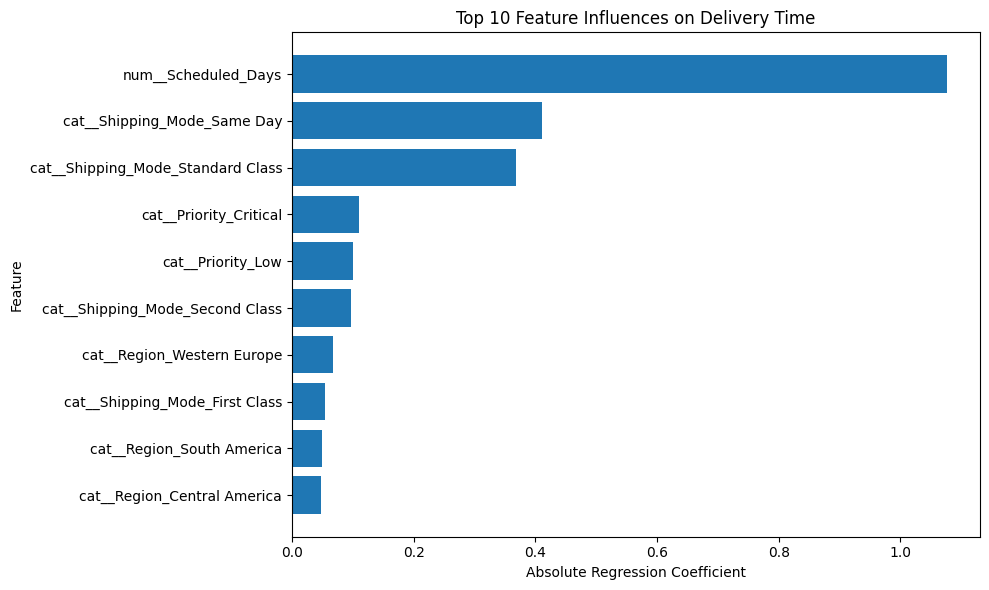

In [25]:
import matplotlib.pyplot as plt

# Select top 10 features
top_features = feature_importance.head(10).sort_values(
    by='Absolute_Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Absolute_Importance']
)

plt.xlabel("Absolute Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Feature Influences on Delivery Time")

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training predictions
y_train_pred = best_model.predict(X_train)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Training Set Results")
print("--------------------")
print(f"MAE  : {train_mae:.3f} days")
print(f"RMSE : {train_rmse:.3f} days")
print(f"R²   : {train_r2:.3f}")

Training Set Results
--------------------
MAE  : 0.964 days
RMSE : 1.169 days
R²   : 0.353


In [27]:
print("\nModel Generalization Comparison")
print("--------------------------------")

print(f"Training MAE : {train_mae:.3f}")
print(f"CV MAE       : {cv_mae.mean():.3f}")
print(f"Test MAE     : {test_mae:.3f}")

print()

print(f"Training RMSE: {train_rmse:.3f}")
print(f"CV RMSE      : {cv_rmse.mean():.3f}")
print(f"Test RMSE    : {test_rmse:.3f}")

print()

print(f"Training R²  : {train_r2:.3f}")
print(f"Test R²      : {test_r2:.3f}")



Model Generalization Comparison
--------------------------------
Training MAE : 0.964
CV MAE       : 0.977
Test MAE     : 0.982

Training RMSE: 1.169
CV RMSE      : 1.188
Test RMSE    : 1.204

Training R²  : 0.353
Test R²      : 0.365


In [28]:
import joblib

# Save the complete trained pipeline
joblib.dump(best_model, "delivery_time_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [29]:
import os

if os.path.exists("delivery_time_prediction_model.pkl"):
    print("File exists: delivery_time_prediction_model.pkl")
    print(f"File size: {os.path.getsize('delivery_time_prediction_model.pkl') / 1024:.2f} KB")
else:
    print("Model file was not found.")

File exists: delivery_time_prediction_model.pkl
File size: 5.19 KB


In [30]:
import joblib

loaded_model = joblib.load("delivery_time_prediction_model.pkl")

print("Model loaded successfully!")


Model loaded successfully!


In [31]:
def predict_delivery_time(
    distance_km,
    shipment_weight_kg,
    order_quantity,
    scheduled_days,
    shipping_mode,
    region,
    product_category,
    priority
):

    new_shipment = pd.DataFrame({
        'Distance_km': [distance_km],
        'Shipment_Weight_kg': [shipment_weight_kg],
        'Order_Quantity': [order_quantity],
        'Scheduled_Days': [scheduled_days],
        'Shipping_Mode': [shipping_mode],
        'Region': [region],
        'Product_Category': [product_category],
        'Priority': [priority]
    })

    prediction = loaded_model.predict(new_shipment)[0]

    return prediction

In [32]:
prediction = predict_delivery_time(
    distance_km=500,
    shipment_weight_kg=10,
    order_quantity=3,
    scheduled_days=4,
    shipping_mode="First Class",
    region="USCA",
    product_category="Technology",
    priority="High"
)

print(f"Predicted Delivery Time: {prediction:.2f} days")

Predicted Delivery Time: 4.77 days


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline: predict the mean delivery time for every test sample
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_prediction)
)
baseline_r2 = r2_score(y_test, baseline_prediction)

print("Baseline Model Results")
print("----------------------")
print(f"Baseline prediction : {y_train.mean():.3f} days")
print(f"MAE                 : {baseline_mae:.3f} days")
print(f"RMSE                : {baseline_rmse:.3f} days")
print(f"R²                  : {baseline_r2:.3f}")

print("\nML Model vs Baseline")
print("--------------------")
print(f"ML Model MAE        : {test_mae:.3f}")
print(f"Baseline MAE        : {baseline_mae:.3f}")
print(f"ML Model RMSE       : {test_rmse:.3f}")
print(f"Baseline RMSE       : {baseline_rmse:.3f}")

Baseline Model Results
----------------------
Baseline prediction : 3.757 days
MAE                 : 1.226 days
RMSE                : 1.512 days
R²                  : -0.001

ML Model vs Baseline
--------------------
ML Model MAE        : 0.982
Baseline MAE        : 1.226
ML Model RMSE       : 1.204
Baseline RMSE       : 1.512


In [35]:
print("Models available:")
for name, model in models.items():
    print(f"\n{name}")
    print(type(model))


Models available:

Linear Regression
<class 'sklearn.linear_model._base.LinearRegression'>

Random Forest
<class 'sklearn.ensemble._forest.RandomForestRegressor'>

Gradient Boosting
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


In [36]:
print("X_train type:", type(X_train))
print("X_test type:", type(X_test))

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nFirst 5 columns:")
print(X_train.columns[:5].tolist() if hasattr(X_train, "columns") else "No column names")

X_train type: <class 'pandas.core.frame.DataFrame'>
X_test type: <class 'pandas.core.frame.DataFrame'>

X_train shape: (1600, 8)
X_test shape: (401, 8)

First 5 columns:
['Distance_km', 'Shipment_Weight_kg', 'Order_Quantity', 'Scheduled_Days', 'Shipping_Mode']


In [38]:
print("Variables containing 'train':")
print([v for v in globals() if 'train' in v.lower()])

print("\nVariables containing 'test':")
print([v for v in globals() if 'test' in v.lower()])

print("\nVariables containing 'transform':")
print([v for v in globals() if 'transform' in v.lower()])

print("\nVariables containing 'preprocess':")
print([v for v in globals() if 'preprocess' in v.lower()])

Variables containing 'train':
['train_test_split', 'X_train', 'y_train', 'y_train_pred', 'train_mae', 'train_rmse', 'train_r2']

Variables containing 'test':
['train_test_split', 'X_test', 'y_test', 'test_mae', 'test_rmse', 'test_r2']

Variables containing 'transform':
['ColumnTransformer', 'numeric_transformer', 'categorical_transformer']

Variables containing 'preprocess':
['preprocessor']


In [39]:
# Transform X_test using the existing fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Original X_test shape   :", X_test.shape)
print("Processed X_test shape  :", X_test_processed.shape)

Original X_test shape   : (401, 8)
Processed X_test shape  : (401, 22)


In [40]:
# Evaluate all original models on the correctly processed test data

results = []

for name, model in models.items():

    y_pred_model = model.predict(X_test_processed)

    mae = mean_absolute_error(y_test, y_pred_model)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))
    r2 = r2_score(y_test, y_pred_model)

    results.append({
        "Model": name,
        "MAE (days)": mae,
        "RMSE (days)": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

print("Final Model Comparison")
print("----------------------")
print(results_df.round(3).to_string(index=False))

Final Model Comparison
----------------------
            Model  MAE (days)  RMSE (days)    R²
Linear Regression       0.982        1.204 0.365
    Random Forest       1.015        1.247 0.319
Gradient Boosting       0.999        1.227 0.341


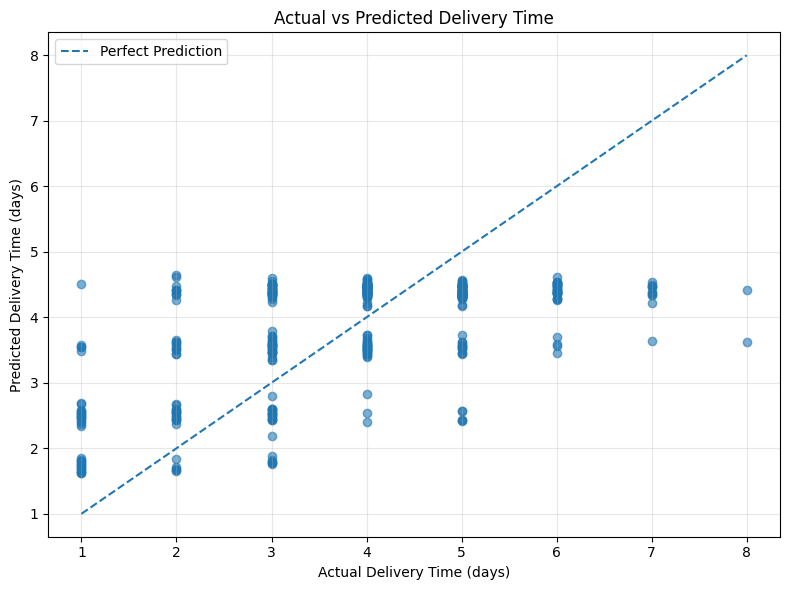

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual Delivery Time (days)")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("Actual vs Predicted Delivery Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

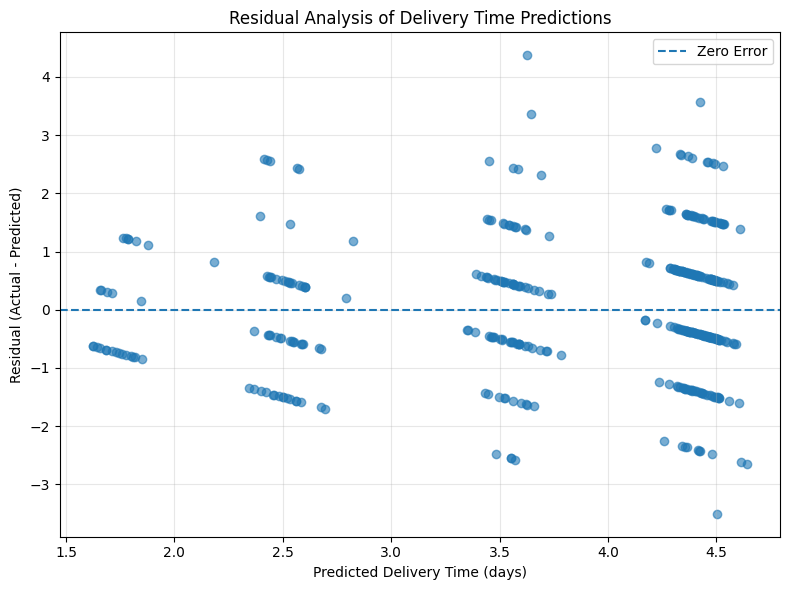

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

# Zero-error reference line
plt.axhline(
    y=0,
    linestyle='--',
    label='Zero Error'
)

plt.xlabel("Predicted Delivery Time (days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis of Delivery Time Predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

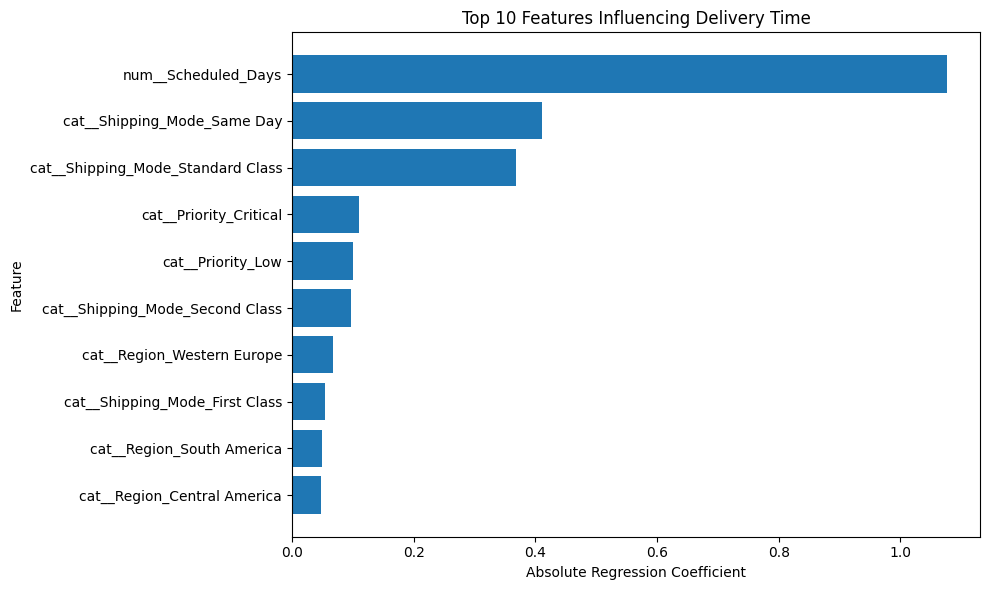

In [44]:
# Top 10 features by absolute coefficient

top_features = feature_importance.head(10).copy()

top_features = top_features.sort_values(
    by="Absolute_Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Importance"]
)

plt.xlabel("Absolute Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Delivery Time")

plt.tight_layout()
plt.show()

In [45]:
final_results = pd.DataFrame({
    "Metric": [
        "Test MAE",
        "Test RMSE",
        "Test R²",
        "5-Fold CV MAE",
        "5-Fold CV RMSE",
        "Predictions within ±1 day",
        "Predictions within ±2 days",
        "Predictions within ±3 days"
    ],
    "Result": [
        f"{test_mae:.3f} days",
        f"{test_rmse:.3f} days",
        f"{test_r2:.3f}",
        f"{cv_mae.mean():.3f} ± {cv_mae.std():.3f} days",
        f"{cv_rmse.mean():.3f} ± {cv_rmse.std():.3f} days",
        f"{within_1:.2f}%",
        f"{within_2:.2f}%",
        f"{within_3:.2f}%"
    ]
})

print("FINAL MODEL PERFORMANCE")
print("=======================")
print(final_results.to_string(index=False))

FINAL MODEL PERFORMANCE
                    Metric             Result
                  Test MAE         0.982 days
                 Test RMSE         1.204 days
                   Test R²              0.365
             5-Fold CV MAE 0.977 ± 0.034 days
            5-Fold CV RMSE 1.188 ± 0.045 days
 Predictions within ±1 day             62.59%
Predictions within ±2 days             90.77%
Predictions within ±3 days             99.00%


In [46]:
import joblib

model_check = joblib.load("delivery_time_prediction_model.pkl")

print("Saved model type:", type(model_check).__name__)
print("Pipeline steps:", list(model_check.named_steps.keys()))

Saved model type: Pipeline
Pipeline steps: ['preprocessor', 'model']


In [47]:
import joblib
import pandas as pd

# Load your saved model
model = joblib.load("delivery_time_prediction_model.pkl")

# Example shipment
new_shipment = pd.DataFrame({
    "Distance_km": [500],
    "Shipment_Weight_kg": [10],
    "Order_Quantity": [3],
    "Scheduled_Days": [4],
    "Shipping_Mode": ["First Class"],
    "Region": ["USCA"],
    "Product_Category": ["Technology"],
    "Priority": ["High"]
})

prediction = model.predict(new_shipment)[0]

print("🚚 DELIVERY TIME PREDICTION")
print("---------------------------")
print(f"Predicted Actual Delivery Time: {prediction:.2f} days")

🚚 DELIVERY TIME PREDICTION
---------------------------
Predicted Actual Delivery Time: 4.77 days
